In [ ]:
import SimpleITK as sitk
import os
import matplotlib.pyplot as plt

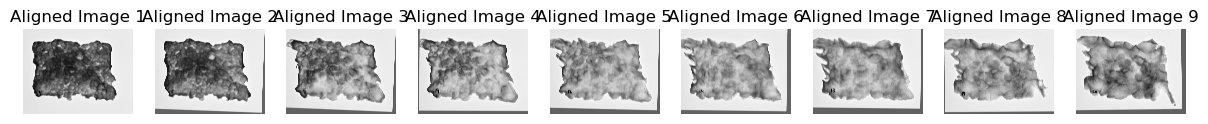

In [32]:
def align_images_sitk(images):
    """Align a series of images using rigid body alignment with SimpleITK."""
    fixed_image = images[0]
    aligned_images = [fixed_image]

    for moving_image in images[1:]:
        # Initialize the transform
        initial_transform = sitk.CenteredTransformInitializer(fixed_image, 
                                                              moving_image, 
                                                              sitk.Euler2DTransform(), 
                                                              sitk.CenteredTransformInitializerFilter.GEOMETRY)

        # Setup for the registration
        registration_method = sitk.ImageRegistrationMethod()

        # Similarity metric settings
        registration_method.SetMetricAsMeanSquares()
        registration_method.SetMetricSamplingStrategy(registration_method.RANDOM)
        registration_method.SetMetricSamplingPercentage(0.1)

        registration_method.SetInterpolator(sitk.sitkLinear)

        # Optimizer settings
        registration_method.SetOptimizerAsGradientDescent(learningRate=1.0, numberOfIterations=100, 
                                                          convergenceMinimumValue=1e-6, convergenceWindowSize=10)
        registration_method.SetOptimizerScalesFromPhysicalShift()

        # Setup for the multi-resolution framework
        registration_method.SetShrinkFactorsPerLevel(shrinkFactors = [4,2,1])
        registration_method.SetSmoothingSigmasPerLevel(smoothingSigmas=[2,1,0])
        registration_method.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

        # Don't optimize in-place, we want to create a new moving image
        registration_method.SetInitialTransform(initial_transform, inPlace=False)

        # Run the registration
        final_transform = registration_method.Execute(fixed_image, moving_image)

        # Resample the moving image to the space of the fixed image
        resampler = sitk.ResampleImageFilter()
        resampler.SetReferenceImage(fixed_image)
        resampler.SetTransform(final_transform)
        resampler.SetInterpolator(sitk.sitkLinear)
        resampler.SetDefaultPixelValue(100)

        aligned_image = resampler.Execute(moving_image)
        aligned_images.append(aligned_image)

    return aligned_images

# Assuming the folder is '/Users/[YourUsername]/Desktop/test'
folder = '/Users/jacobwiniski/Desktop/test'  # Replace [YourUsername] with your actual username
sitk_images = load_sitk_images_from_folder(folder)

# Align the images
aligned_sitk_images = align_images_sitk(sitk_images)

# Convert SimpleITK images to numpy arrays for visualization
aligned_numpy_images = [sitk.GetArrayFromImage(img) for img in aligned_sitk_images]

# Display the first few aligned images for verification
plt.figure(figsize=(15, 10))
for i, img in enumerate(aligned_numpy_images[:9]):
    plt.subplot(1, 9, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Aligned Image {i+1}")
    plt.axis('off')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def create_3d_visualization(aligned_images, slice_thickness_mm=2):
    # Calculate pixel size in mm
    pixel_size_x_mm = 300 / len(aligned_images[0][0])  # Width of each pixel in mm
    pixel_size_y_mm = 160 / len(aligned_images[0])     # Height of each pixel in mm

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Calculate the number of slices and their positions in mm
    num_slices = len(aligned_images)
    slice_positions = np.arange(0, num_slices * slice_thickness_mm, slice_thickness_mm)

    # Loop through each slice and plot it in 3D space
    for i, slice_img in enumerate(aligned_images):
        X, Y = np.meshgrid(np.linspace(0, 300, len(slice_img[0])), np.linspace(0, 160, len(slice_img)))
        Z = np.ones_like(X) * slice_positions[i]

        # Normalize the image for proper colormap display
        normalized_img = slice_img / np.max(slice_img)

        # Plot each slice as a surface
        ax.plot_surface(X, Z, Y, rstride=1, cstride=1, facecolors=plt.cm.gray(normalized_img), shade=False)

    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Z (mm)')
    ax.set_zlabel('Y (mm)')
    ax.set_title('3D Visualization of Aligned Image Stack')

    plt.show()

# Visualize the 3D stack
create_3d_visualization(aligned_numpy_images)

